# Creative Health & Explainability Dashboard

**Goal:** Interactive SHAP + survival curves + health score per creative.

**Data:** `creative_merged.csv` only — **prelaunch / static** creative fields (vertical, format, theme, hook_type, copy, text scores, flags, etc.). **Excluded:** any `first_7d_*`, `last_7d_*`, `overall_*`, `total_*`, decay, peak, and `perf_score` columns (no `creative_daily_country_os_stats.csv`, no campaign-level joins).

Survival labels still use `fatigue_day` / `total_days_active` **only** to define event and censoring time — they are not model inputs.

## 1. Setup & Imports

In [21]:
import sys
# Workaround for numpy 2.x incompatibilities with older optional dependencies
sys.modules['bottleneck'] = None
sys.modules['numexpr'] = None

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
import scipy.stats as stats
import shap
import ipywidgets as widgets
from IPython.display import display, clear_output
import IPython.display as ipd

pd.set_option('display.max_columns', 60)
np.random.seed(42)

DATA = '../data'
TIME_GRID = np.arange(0, 75, 1).astype(float)

print('Imports OK.')

Imports OK.


## 2. Data loading & prelaunch (static-only) features

In [22]:
from sklearn.preprocessing import OrdinalEncoder

surv = pd.read_csv(f"{DATA}/creative_merged.csv")

surv["event"] = (surv["creative_status"] == "fatigued").astype(bool)
surv["duration"] = np.where(surv["event"], surv["fatigue_day"], surv["total_days_active"]).astype(float)
surv = surv.reset_index(drop=True)

# Prelaunch static: creative/asset/copy only (no delivery KPIs, no campaign join).
STATIC_CAT = [
    "vertical", "format", "language", "theme", "hook_type",
    "cta_text", "headline", "subhead", "dominant_color", "emotional_tone",
]
STATIC_NUM = [
    "width", "height",
    "duration_sec", "text_density", "copy_length_chars", "readability_score",
    "brand_visibility_score", "clutter_score", "novelty_score", "motion_score",
    "faces_count", "product_count",
]
STATIC_BIN = ["has_price", "has_discount_badge", "has_gameplay", "has_ugc_style"]

STATIC_CAT = [c for c in STATIC_CAT if c in surv.columns]
STATIC_NUM = [c for c in STATIC_NUM if c in surv.columns]
STATIC_BIN = [c for c in STATIC_BIN if c in surv.columns]

feat_cols = STATIC_CAT + STATIC_NUM + STATIC_BIN
Xraw = surv[feat_cols].copy()
for c in STATIC_NUM:
    Xraw[c] = pd.to_numeric(Xraw[c], errors="coerce")
for c in STATIC_BIN:
    Xraw[c] = pd.to_numeric(Xraw[c], errors="coerce").fillna(0)

y = Surv.from_arrays(event=surv["event"].values, time=surv["duration"].values)

idx_train, idx_test = train_test_split(
    np.arange(len(surv)), test_size=0.20, stratify=surv["event"], random_state=42
)

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(Xraw.iloc[idx_train][STATIC_CAT].astype(str))
X_cat = pd.DataFrame(enc.transform(Xraw[STATIC_CAT].astype(str)), columns=STATIC_CAT, index=surv.index)
num_med = Xraw.iloc[idx_train][STATIC_NUM].median()
X_num = Xraw[STATIC_NUM].fillna(num_med)
X_bin = Xraw[STATIC_BIN]

X = pd.concat([X_cat, X_num, X_bin], axis=1)
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(
    f"Train: {len(X_train)} | Test: {len(X_test)} | "
    f"Features ({len(feat_cols)}): creative_merged static only (no daily CSV)."
)

Train: 864 | Test: 216 | Features (26): creative_merged static only (no daily CSV).


## 3. Train Random Survival Forest

In [23]:
rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
rsf.fit(X_train.values, y_train)
print("RSF trained on prelaunch (static-only) features.")

RSF trained on prelaunch (static-only) features.


## 4. SHAP Global Explainability
Calculate SHAP values for the test set to understand the global impact of features on the risk score.

SHAP ready (surrogate trained on train split).


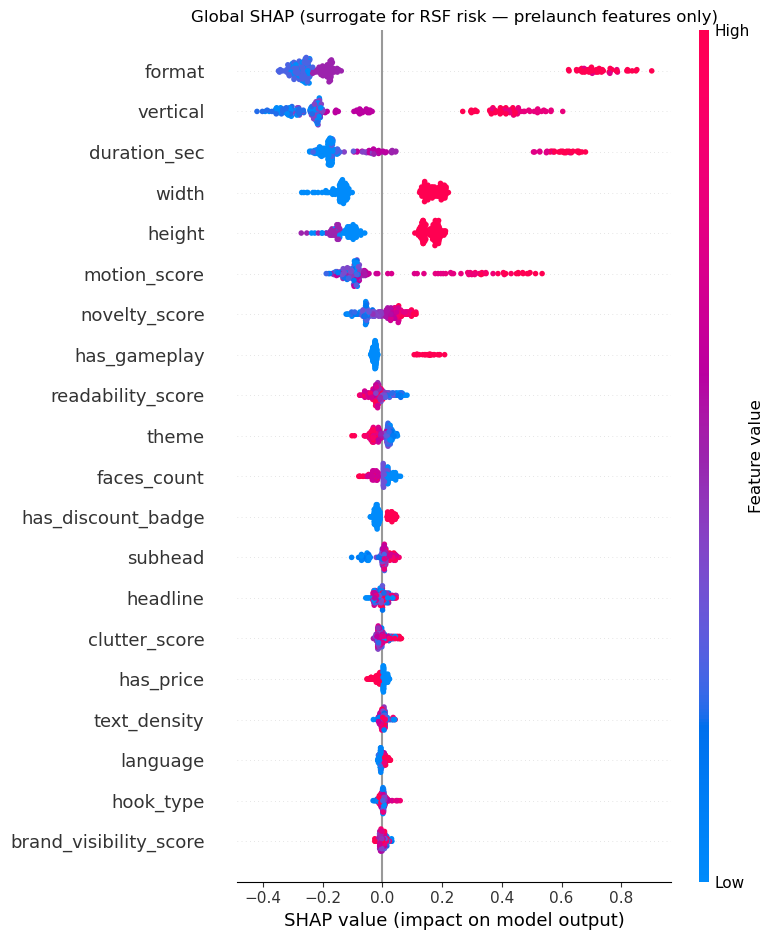

In [24]:
# TreeExplainer does not support RandomSurvivalForest: surrogate regressor on train risk.
from sklearn.ensemble import RandomForestRegressor

risk_train = rsf.predict(X_train.values)
surrogate = RandomForestRegressor(
    n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42
)
surrogate.fit(X_train.values, risk_train)

explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_test.values)
shap_obj = explainer(X_test)
print("SHAP ready (surrogate trained on train split).")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title("Global SHAP (surrogate for RSF risk — prelaunch features only)")
plt.tight_layout()
plt.show()

## 5. The Creative Health Platform (Interactive Dashboard)

Select a `creative_id` from the dropdown to see its specific:
1. **Survival Curve**: Probability of survival over time.
2. **Innate Health Score**: Un valor de 0 a 100 basado en el percentil de riesgo (f(x)) comparado con la media histórica.
3. **Local SHAP Explanations**: Why the model predicted this specific risk score based on the creative's features.

In [25]:
test_creatives = surv.iloc[idx_test]['creative_id'].values
dropdown = widgets.Dropdown(options=test_creatives, description='Creative ID:')
out = widgets.Output()

# Precompute training risk scores to find percentiles
train_risk_scores = rsf.predict(X_train.values)

def plot_health_dashboard(creative_id):
    with out:
        clear_output(wait=True)
        
        # 1. Gather Data
        orig_idx = surv[surv['creative_id'] == creative_id].index[0]
        test_pos = np.where(idx_test == orig_idx)[0]
        if len(test_pos) == 0:
            print("Creative not found in test set.")
            return
        test_idx = test_pos[0]
        
        row_data = surv.iloc[orig_idx]
        x_features = X_test.iloc[[test_idx]]
        
        # 2. Predicted survival curve
        surv_fn = rsf.predict_survival_function(x_features.values)[0]
        times = surv_fn.x
        probs = surv_fn(times)
        
        # 3. Calculate Risk Percentile Health Score
        risk_score = rsf.predict(x_features.values)[0]
        risk_percentile = stats.percentileofscore(train_risk_scores, risk_score)
        health_score = 100.0 - risk_percentile
        health_color = '#27AE60' if health_score >= 60 else ('#F39C12' if health_score >= 30 else '#E74C3C')
            
        current_age = row_data['duration']
        status = row_data['creative_status']
        
        # 4. Render HTML Title and Attributes
        display(ipd.HTML(f"""
        <div style="background-color:#2C3E50; padding:15px; border-radius:10px; color:white; font-family:sans-serif;">
            <h2 style="margin:0; color:#F1C40F;">Creative Analysis: {creative_id}</h2>
            <p><b>Status:</b> {status} | <b>Duration Active:</b> {int(current_age)} days | <b>Format:</b> {row_data['format']} | <b>Vertical:</b> {row_data['vertical']}</p>
        </div>
        """))
        
        fig = plt.figure(figsize=(16, 12))
        
        # Plot 1: Survival Curve
        ax1 = plt.subplot(2, 2, 1)
        ax1.step(times, probs, where='post', color='#2980B9', lw=3)
        if status == 'fatigued':
            ax1.axvline(current_age, color='red', linestyle='--', lw=2, label=f'Fatigue Day ({int(current_age)}d)')
        ax1.set_ylim(0, 1.05)
        ax1.set_title('Predicted Survival Curve S(t)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Days since launch', fontsize=12)
        ax1.set_ylabel('Probability of Survival', fontsize=12)
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # Plot 2: Risk Histogram & Health Score
        ax2 = plt.subplot(2, 2, 2)
        ax2.hist(train_risk_scores, bins=40, color='#BDC3C7', alpha=0.7, density=True)
        ax2.axvline(risk_score, color=health_color, linestyle='-', lw=4, label=f'This Creative f(x) = {risk_score:.2f}')
        ax2.set_title(f'Innate Health Score: {int(health_score)}/100', fontsize=16, fontweight='bold', color=health_color)
        ax2.set_xlabel('Model Risk Score f(x) Distribution', fontsize=12)
        ax2.set_ylabel('Density', fontsize=12)
        ax2.grid(alpha=0.3)
        ax2.legend()
        
        # Plot 3: Local SHAP Waterfall Plot
        ax3 = plt.subplot(2, 2, (3, 4))
        plt.title(f'Local SHAP Explanations (Why is the risk score f(x)={risk_score:.2f}?)', fontsize=14, fontweight='bold')
        # SHAP expects the current axis for waterfall, so we don't need to pass ax explicitly
        shap.waterfall_plot(shap_obj[test_idx], max_display=10, show=False)
        
        plt.tight_layout()
        plt.show()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        plot_health_dashboard(change['new'])

dropdown.observe(on_change)
display(dropdown)
display(out)

# Trigger initial plot
plot_health_dashboard(dropdown.value)

Dropdown(description='Creative ID:', options=(np.int64(500015), np.int64(500069), np.int64(500570), np.int64(5…

Output()